<a href="https://colab.research.google.com/github/DariaChernykh4/data-analytics-projects/blob/main/python-projects/rfm-segmentation/rfm_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**RFM Customer Segmentation (email engagement)**

**Steps to complete the task:**

1. Write SQL code to retrieve a dataset for analysis containing the following data:
   - **visit_cnt** - the number of unique emails opened by the account;
   - **last_visit_date** - the date of the last email open;
   - **revenue** - we will assume an average revenue of $10 for every email opened by a user.

In [1]:
## SQL-код
"""
SELECT
ac.id as account_id,
COUNT(DISTINCT ev.id_message) as visit_cnt,
MAX(DATE_ADD(s.date, INTERVAL ev.visit_date DAY)) as last_visit_date,
COUNT(DISTINCT eo.id_message)*10 as revenue
FROM `DA.account` ac
JOIN `DA.account_session` acs
ON ac.id = acs.account_id
JOIN `DA.session` s
ON acs.ga_session_id = s.ga_session_id
LEFT JOIN `DA.email_visit` ev
ON ac.id = ev.id_account
LEFT JOIN `DA.email_open` AS eo
ON ac.id = eo.id_account
GROUP BY ac.id
HAVING visit_cnt>0;
"""

'\nSELECT\nac.id as account_id,\nCOUNT(DISTINCT ev.id_message) as visit_cnt,\nMAX(DATE_ADD(s.date, INTERVAL ev.visit_date DAY)) as last_visit_date,\nCOUNT(DISTINCT eo.id_message)*10 as revenue\nFROM `DA.account` ac\nJOIN `DA.account_session` acs\nON ac.id = acs.account_id\nJOIN `DA.session` s\nON acs.ga_session_id = s.ga_session_id\nLEFT JOIN `DA.email_visit` ev\nON ac.id = ev.id_account\nLEFT JOIN `DA.email_open` AS eo\nON ac.id = eo.id_account\nGROUP BY ac.id\nHAVING visit_cnt>0;\n'

2. Create a dictionary to assign a specific value to each RFM scale. Also, you need to review the current situation and break down each metric into segments:
- *How long ago did the user open their last email?* Here, you can use the latest available date across all subscribers as a reference point to calculate the time elapsed (e.g., one or two days ago).
- *What is the total number of visits?*
- *How much revenue did we generate per user?*

In [2]:
from google.colab import drive
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Product and Marketing Metrics

/content/drive/MyDrive/Product and Marketing Metrics


In [4]:
data = pd.read_csv("data.csv")

In [5]:
data.head()

,account_id,visit_cnt,last_visit_date,revenue
0,671969,4,2021-01-09,620
1,668655,3,2021-02-07,70
2,673773,5,2020-12-27,640
3,661850,1,2020-12-16,350
4,664958,1,2020-12-07,30


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       4463 non-null   int64 
 1   visit_cnt        4463 non-null   int64 
 2   last_visit_date  4463 non-null   object
 3   revenue          4463 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 139.6+ KB


In [7]:
data["last_visit_date"] = pd.to_datetime(data["last_visit_date"])

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   account_id       4463 non-null   int64         
 1   visit_cnt        4463 non-null   int64         
 2   last_visit_date  4463 non-null   datetime64[ns]
 3   revenue          4463 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 139.6 KB


In [9]:
# Set analysis date
analysis_date = data["last_visit_date"].max()
analysis_date

Timestamp('2021-02-25 00:00:00')

In [10]:
# Check RFM disribution
temp = data.groupby("account_id").agg({
    "last_visit_date": lambda x: (analysis_date - x.max()).days,
    "visit_cnt": "sum",
    "revenue": "sum"
}).reset_index()
temp.columns = ["account_id", "recency", "frequency", "monetary"]

print(temp[["recency", "frequency", "monetary"]].describe())

           recency    frequency     monetary
count  4463.000000  4463.000000  4463.000000
mean     59.268877     4.632982   325.254313
std      26.749646     5.795306   361.307975
min       0.000000     1.000000    10.000000
25%      38.000000     1.000000    70.000000
50%      60.000000     3.000000   180.000000
75%      80.000000     6.000000   450.000000
max     116.000000    65.000000  2040.000000


In [11]:
# Calculate RFM metrics
def calculate_rfm(data, analysis_date):
  rfm = data.groupby("account_id").agg({
      "last_visit_date": lambda x: (analysis_date - x.max()).days,
      "visit_cnt": "sum",
      "revenue": "sum"
  }).reset_index()
  rfm.columns = ["account_id", "recency", "frequency", "monetary"]

  # Create R, F, M quartiles
  # Recency bins: 25th and 75th percentiles (38, 80 days)
  rfm["R"] = pd.cut(rfm["recency"], bins=[-1, 38, 80, float('inf')], labels=[3, 2, 1])
  # Frequency bins: 50th and 75th percentiles (3, 6 visits) — 25th percentile is 1, too low for a meaningful split
  rfm["F"] = pd.cut(rfm["frequency"], bins=[0, 3, 6, float('inf')], labels=[1, 2, 3], include_lowest=True)
  # Monetary bins: 50th and 75th percentiles ($180, $450) — 25th percentile is $70, too low for a meaningful split
  rfm["M"] = pd.cut(rfm["monetary"], bins=[0, 180, 450, float('inf')], labels=[1, 2, 3], include_lowest=True)

  # Calculate RFM score
  rfm["rfm_score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

  # Calculate RFM Value
  rfm["rfm_value"] = rfm[["R", "F", "M"]].mean(axis=1)

  return rfm

In [12]:
# Calculate RFM
rfm_results = calculate_rfm(data, analysis_date)

In [13]:
# Define customer segments
def segment_customers(value):
   if value >= 2.5:
       return "Top"
   elif value >= 1.5:
       return "Middle"
   else:
       return "Lost"

# Add segment labels
rfm_results["customer_segment"] = rfm_results["rfm_value"].apply(segment_customers)

In [14]:
# Summary statistics
print("Customer Segments Distribution:")
print(rfm_results["customer_segment"].value_counts())
print("\nRFM Metrics Summary Statistics:")
print(rfm_results[["recency", "frequency", "monetary"]].describe())

# Sample of the final RFM table
print("\nSample RFM Results (First 10 customers):")
print(rfm_results.head(10).to_string())

Customer Segments Distribution:
customer_segment
Middle    2347
Lost      1599
Top        517
Name: count, dtype: int64

RFM Metrics Summary Statistics:
           recency    frequency     monetary
count  4463.000000  4463.000000  4463.000000
mean     59.268877     4.632982   325.254313
std      26.749646     5.795306   361.307975
min       0.000000     1.000000    10.000000
25%      38.000000     1.000000    70.000000
50%      60.000000     3.000000   180.000000
75%      80.000000     6.000000   450.000000
max     116.000000    65.000000  2040.000000

Sample RFM Results (First 10 customers):
   account_id  recency  frequency  monetary  R  F  M rfm_score  rfm_value customer_segment
0      657112       76          2        60  2  1  1       211   1.333333             Lost
1      657160        5          4        80  3  2  1       321   2.000000           Middle
2      657185       69          1        70  2  1  1       211   1.333333             Lost
3      657197       20          1   

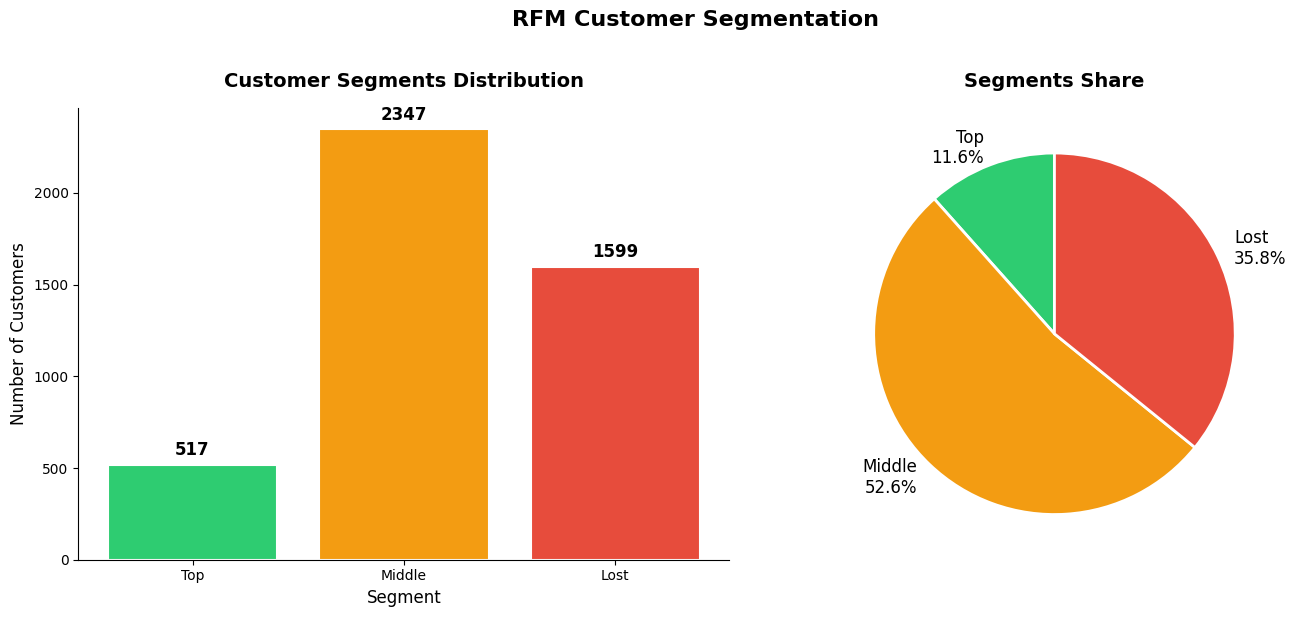

In [15]:
# Create segment visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Count
segment_order = ["Top", "Middle", "Lost"]
colors = {"Top": "#2ecc71", "Middle": "#f39c12", "Lost": "#e74c3c"}

counts = rfm_results["customer_segment"].value_counts().reindex(segment_order)

bars = axes[0].bar(counts.index, counts.values,
                   color=[colors[s] for s in counts.index], edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 str(val), ha="center", va="bottom", fontweight="bold", fontsize=12)

axes[0].set_title("Customer Segments Distribution", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Segment", fontsize=12)
axes[0].set_ylabel("Number of Customers", fontsize=12)
axes[0].spines[["top", "right"]].set_visible(False)

# Plot 2: Pie
pct_values = counts.values / counts.values.sum() * 100

axes[1].pie(counts.values,
            labels=[f"{s}\n{v:.1f}%" for s, v in zip(counts.index, pct_values)],
            colors=[colors[s] for s in counts.index],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2},
            textprops={"fontsize": 12})

axes[1].set_title("Segments Share", fontsize=14, fontweight="bold", pad=15)

plt.suptitle("RFM Customer Segmentation", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Segment Distribution:**

* Top - 517 customers (11.6%)
* Middle - 2347 customers (52.6%)
* Lost - 1599 customers (35.8%)

**Top (11.6%)** - the most active subscribers: they opened emails recently (within the last 38 days), do so frequently (6+ times), and generate the highest revenue ($450+). These customers should be encouraged to remain engaged with the email channel through personalized communication, exclusive offers, and loyalty programs.

**Middle (52.6%)** - the largest segment of the customer base: they last opened emails 38-80 days ago, have 3-6 visits, and generate $180-450 in revenue. This segment should remain a key engagement target. Regular communication with valuable content and targeted incentives can help move some customers into the Top segment.

**Lost (35.8%)** - a significant share of the customer base. These customers have not opened emails for 80+ days, have low engagement frequency, and generate minimal revenue. They should first be targeted with a **win-back or reactivation campaign**, using relevant offers or personalized content to encourage renewed engagement. Customers who remain inactive after the reactivation attempt can then be gradually excluded from regular email communication to reduce unnecessary messaging.
